<a href="https://colab.research.google.com/github/marioarsw/AnaliticaDescriptiva/blob/main/practicas/267379_03_semana11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maestría en Inteligencia Artificial y Analítica de Datos


*   Curso: Programación para Analítica Descriptiva y Predictiva
*   Semestre: Enero-Junio
*   Profesor: Dr. Vicente García Jiménez

## Mario Amador - 267370

### **Instrucciones y Objetivos para la Práctica: Regresión Lasso y Ridge**

#### **📌 Objetivos de la Práctica:**  
Al finalizar esta práctica, los estudiantes serán capaces de:  
1. **Realizar un Análisis Exploratorio de Datos (EDA)** completo, incluyendo visualización de distribuciones, detección de outliers y análisis de correlaciones.  
2. **Preprocesar datos** correctamente, manejando valores faltantes, codificando variables categóricas y escalando características.  
3. **Implementar modelos de regresión Lasso y Ridge**, entendiendo cómo la regularización afecta los coeficientes.  
4. **Verificar los supuestos de la regresión lineal** (linealidad, normalidad de residuos, homocedasticidad y multicolinealidad).  
5. **Comparar el rendimiento** de ambos modelos y analizar qué variables son más relevantes en cada caso.  

### **📋 Instrucciones**  

#### **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual
✅ Ejecutar las celdas de importación de librerías y carga del dataset.  
✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.

In [5]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Estadística
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/Unidad03/insurance.csv')

In [6]:
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [8]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


## **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  

📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.  

In [9]:
variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns
variables_categoricas = df.select_dtypes(include=['object']).columns

print("Variables numéricas:", list(variables_numericas))
print("Variables categóricas:", list(variables_categoricas))

Variables numéricas: ['age', 'bmi', 'children', 'charges']
Variables categóricas: ['sex', 'smoker', 'region']


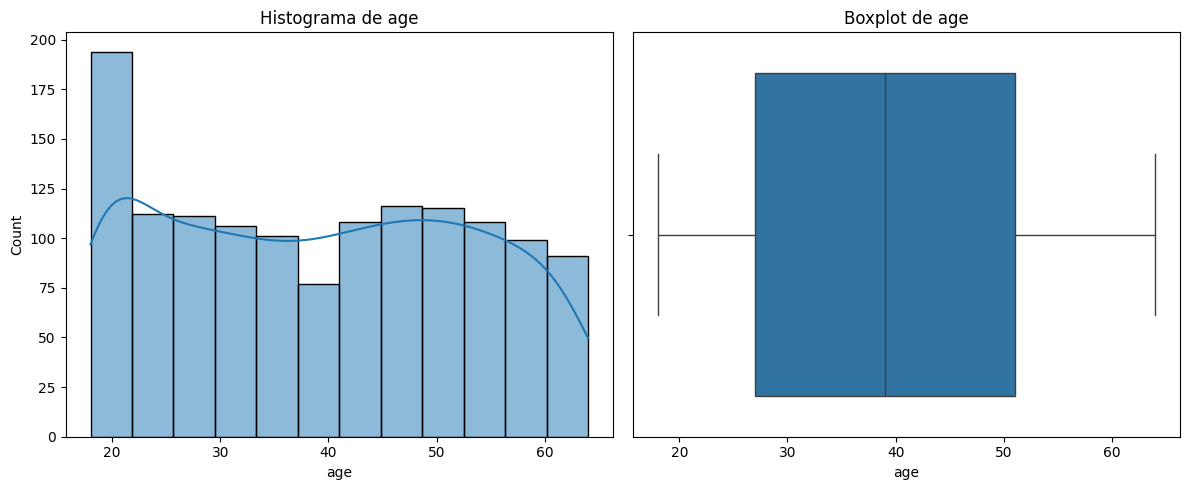

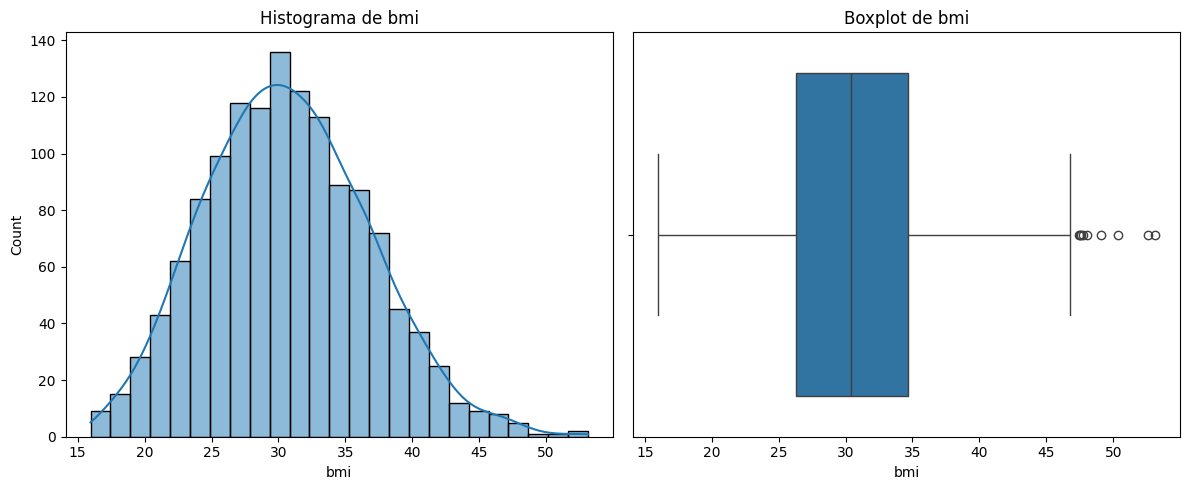

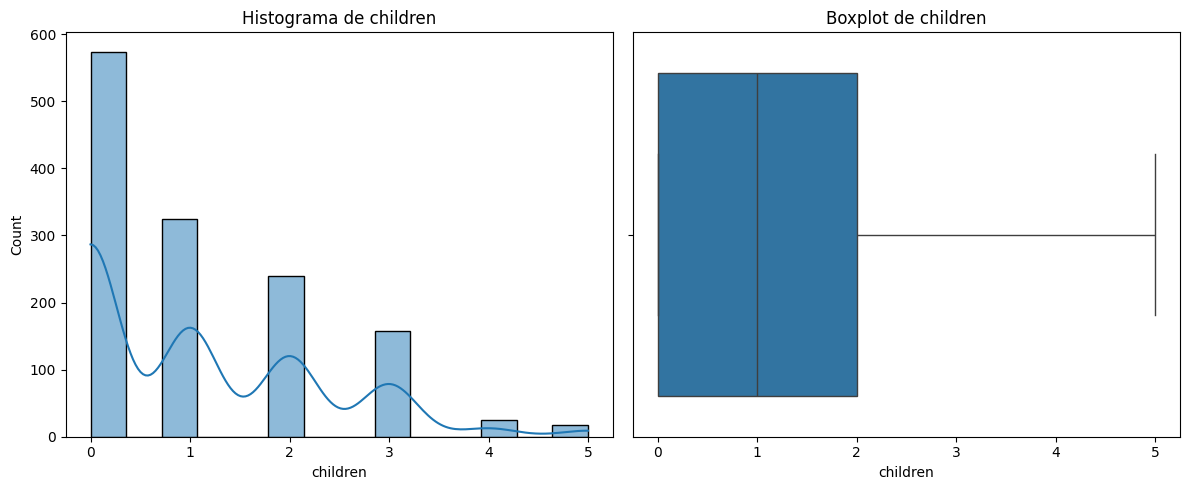

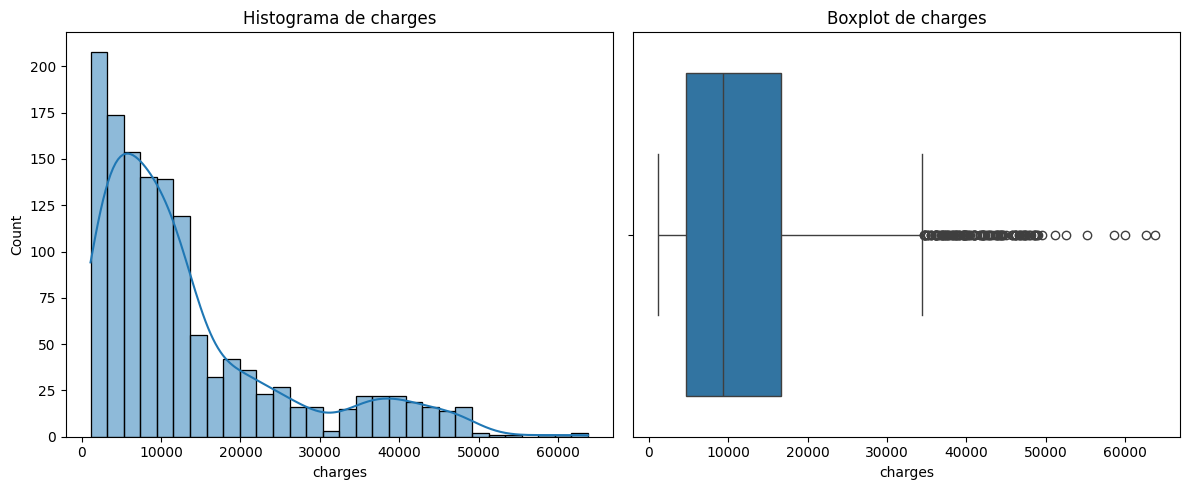

In [10]:
# =========================================
# 1. Variables numéricas
# Histogramas + Boxplots
# =========================================

for col in variables_numericas:
    plt.figure(figsize=(12,5))

    # Histograma
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histograma de {col}')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')

    plt.tight_layout()
    plt.show()

In [11]:
print("\nMedidas de tendencia central y dispersión:\n")

resumen_estadistico = pd.DataFrame({
    'Media': df[variables_numericas].mean(),
    'Mediana': df[variables_numericas].median(),
    'Moda': df[variables_numericas].mode().iloc[0],
    'Desv. Estándar': df[variables_numericas].std(),
    'Varianza': df[variables_numericas].var(),
    'Mínimo': df[variables_numericas].min(),
    'Máximo': df[variables_numericas].max(),
    'Rango': df[variables_numericas].max() - df[variables_numericas].min()
})

print(resumen_estadistico)


Medidas de tendencia central y dispersión:

                 Media   Mediana       Moda  Desv. Estándar      Varianza  \
age          39.207025    39.000    18.0000       14.049960  1.974014e+02   
bmi          30.663397    30.400    32.3000        6.098187  3.718788e+01   
children      1.094918     1.000     0.0000        1.205493  1.453213e+00   
charges   13270.422265  9382.033  1639.5631    12110.011237  1.466524e+08   

             Mínimo       Máximo        Rango  
age         18.0000     64.00000     46.00000  
bmi         15.9600     53.13000     37.17000  
children     0.0000      5.00000      5.00000  
charges   1121.8739  63770.42801  62648.55411  


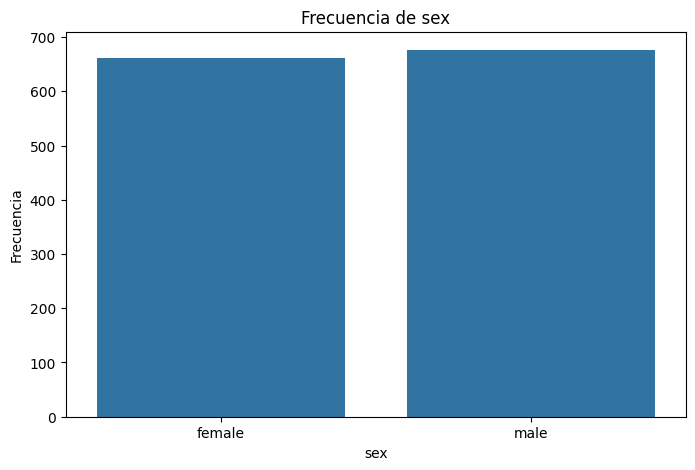

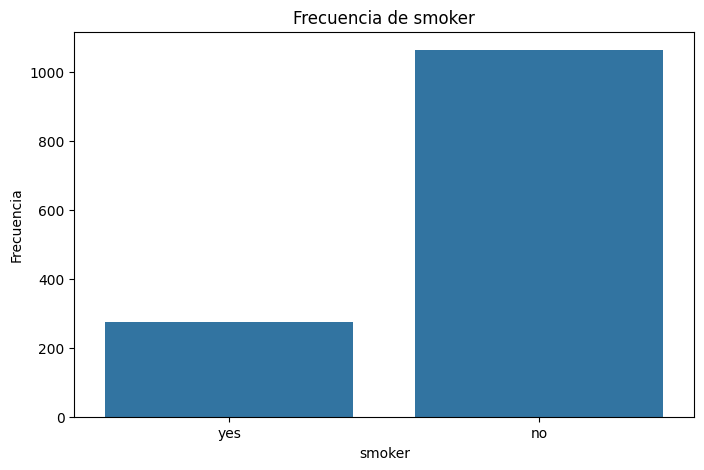

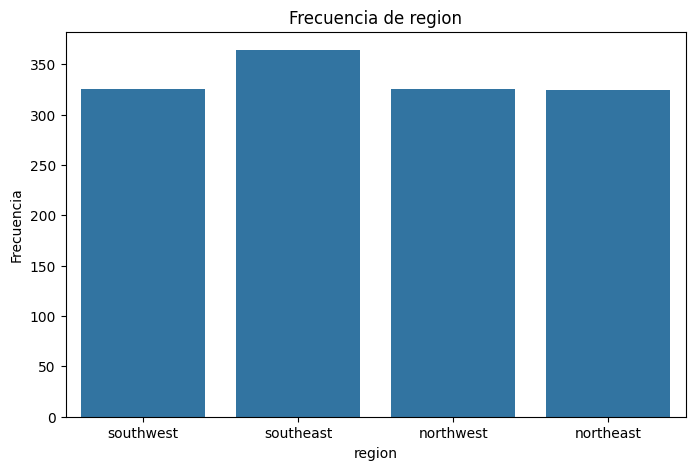

In [12]:
# =========================================
# 2. Variables categóricas
# Gráficos de barras de frecuencias
# =========================================

for col in variables_categoricas:
    plt.figure(figsize=(8,5))
    sns.countplot(x=df[col])
    plt.title(f'Frecuencia de {col}')
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()


In [14]:
pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.9 MB/s eta 0:00:00


In [15]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Reporte EDA - Insurance Dataset",
    explorative=True
)

# Mostrar en notebook
profile.to_notebook_iframe()

/tmp/ipykernel_5575/2698556725.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 70.00it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

#### 1. Análisis de Variables Numéricas

Las variables numéricas analizadas fueron:

- `age`
- `bmi`
- `children`
- `charges`

Para cada una se generaron histogramas y boxplots.

---

##### Variable objetivo: `charges`

Esta es la variable más importante del análisis, ya que representa el costo del seguro médico y será la variable dependiente en los modelos de regresión.

##### Histograma de `charges`

El histograma muestra una distribución claramente sesgada hacia la derecha (asimetría positiva), lo que indica que:

- La mayoría de los clientes tienen costos médicos relativamente bajos o moderados.
- Existe un grupo pequeño de clientes con costos extremadamente altos.

Esto sugiere que la variable no sigue una distribución normal.

##### Boxplot de `charges`

El boxplot confirma la presencia de una gran cantidad de valores atípicos (outliers) en la parte superior.

Esto significa que existen personas cuyos gastos médicos son mucho mayores que el promedio, posiblemente asociados a factores como:

- ser fumador (`smoker`)
- mayor edad
- IMC elevado (`bmi`)
- enfermedades de alto costo

Estos outliers son importantes porque pueden influir significativamente en los modelos de regresión.

---

##### 2. Medidas de Tendencia Central y Dispersión

##### Variable `charges`

| Medida | Valor |
|---|---:|
| Media | 13,270.42 |
| Mediana | 9,382.03 |
| Moda | 1,639.56 |
| Desviación estándar | 12,110.01 |

##### Interpretación

Se observa que:

**Media > Mediana > Moda**

Esto confirma nuevamente una distribución sesgada positivamente, causada por los valores extremos altos.

Además:

- La desviación estándar es bastante elevada, lo que indica alta dispersión.
- El rango también es muy amplio (`62,648`), reforzando la gran variabilidad en los costos médicos.

Esto es muy común en datasets de seguros y salud.

---

##### Variable `age`

- Edad promedio: 39 años
- Mediana: 39 años
- Moda: 18 años

La distribución parece relativamente equilibrada, aunque existe una mayor concentración en edades jóvenes.

---

##### Variable `bmi`

- Promedio: 30.66

Este valor ya se encuentra en rango de sobrepeso/obesidad leve, lo cual puede tener una fuerte relación con mayores costos médicos.

---

##### Variable `children`

- Moda: 0 hijos

La mayoría de los asegurados no tienen hijos o tienen pocos dependientes.

---

##### 3. Variables Categóricas

Se analizaron mediante gráficos de barras.

---

##### Variable `smoker`

El gráfico muestra una fuerte diferencia entre ambas categorías:

- La mayoría de los clientes **NO son fumadores**
- Una minoría sí pertenece al grupo de fumadores

Esto es especialmente importante porque en este dataset, normalmente `smoker` suele ser una de las variables con mayor impacto sobre `charges`.

Frecuentemente los fumadores presentan costos médicos considerablemente más altos.

Por ello, esta variable probablemente será una de las más relevantes en Lasso y Ridge.

---

##### Conclusión del EDA

El análisis exploratorio permitió identificar varios hallazgos importantes:

- La variable objetivo `charges` presenta fuerte asimetría positiva
- Existen numerosos outliers relevantes
- La variable `smoker` parece tener alta influencia potencial
- `bmi` también podría ser una variable importante
- Será necesario un buen preprocesamiento antes de modelar, especialmente:
  - codificación de variables categóricas
  - escalado de variables
  - validación de supuestos de regresión

Este paso es fundamental porque ayuda a entender el comportamiento real de los datos antes de aplicar Lasso y Ridge.

## **🔹 Paso 3: Matriz de Correlación**  
✅ Calcular la matriz de correlación **solo para variables numéricas**.  
✅ Generar un **mapa de calor** para visualizar relaciones.  
📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)?  

Matriz de correlación:
               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


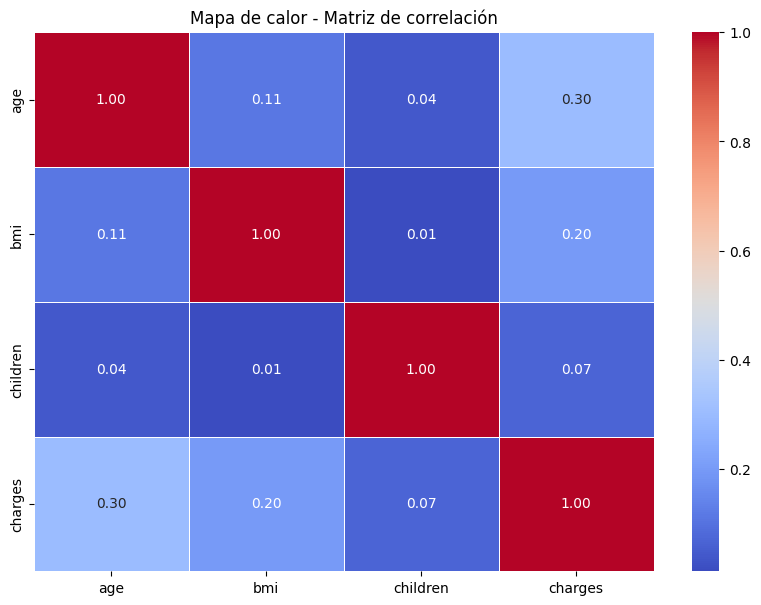


Correlación de las variables con 'charges':
charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


In [17]:
# =========================================
# Paso 3: Matriz de Correlación
# =========================================

# Seleccionar únicamente variables numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# Calcular matriz de correlación
matriz_correlacion = df_numerico.corr()

print("Matriz de correlación:")
print(matriz_correlacion)

# =========================================
# Heatmap de correlación
# =========================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Mapa de calor - Matriz de correlación")
plt.show()

# =========================================
# Correlación con la variable objetivo
# =========================================

correlacion_charges = matriz_correlacion["charges"].sort_values(ascending=False)

print("\nCorrelación de las variables con 'charges':")
print(correlacion_charges)

### Análisis del Paso 3: Matriz de Correlación

En esta etapa se calculó la matriz de correlación utilizando únicamente las variables numéricas del dataset:

- `age`
- `bmi`
- `children`
- `charges`

El objetivo fue identificar qué tan relacionadas están estas variables entre sí y, especialmente, cuáles tienen mayor relación con la variable objetivo `charges`, que representa el costo del seguro médico.

---

### Matriz de correlación

La correlación de Pearson toma valores entre:

- **+1** → relación positiva perfecta
- **0** → sin relación lineal
- **-1** → relación negativa perfecta

Mientras más cercano esté el valor a 1 o -1, mayor será la relación entre variables.

---

### Correlación con la variable objetivo (`charges`)

Los resultados obtenidos fueron:

| Variable | Correlación con charges |
|---|---:|
| age | 0.30 |
| bmi | 0.20 |
| children | 0.07 |

---

### Interpretación de resultados

#### 1. `age` → correlación de 0.30

Es la variable numérica con mayor relación respecto a `charges`.

Esto indica una correlación positiva moderada, lo que sugiere que conforme aumenta la edad, también tienden a aumentar los gastos médicos.

Esto tiene sentido, ya que generalmente las personas mayores requieren mayor atención médica y presentan mayores riesgos de salud.

---

#### 2. `bmi` → correlación de 0.20

Presenta una correlación positiva baja, pero relevante.

Esto sugiere que un mayor índice de masa corporal puede estar asociado con mayores costos médicos, especialmente en casos de sobrepeso u obesidad.

Aunque la relación no es muy fuerte, sigue siendo una variable importante para el modelo.

---

#### 3. `children` → correlación de 0.07

La correlación es muy baja, prácticamente cercana a cero.

Esto indica que la cantidad de hijos tiene poca influencia directa sobre el costo del seguro médico en este dataset.

Probablemente esta variable tendrá poca relevancia en los modelos de regresión.

---

### Relación entre variables predictoras

También se observa que no existe una alta correlación entre las variables independientes:

- `age` y `bmi` → 0.11
- `age` y `children` → 0.04
- `bmi` y `children` → 0.01

Esto es una buena señal, ya que reduce el riesgo de multicolinealidad, uno de los supuestos importantes en regresión lineal.

---

### Conclusión

Las variables numéricas más relacionadas con el target `charges` son:

1. `age`
2. `bmi`

Mientras que `children` presenta una influencia mucho menor.

## **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.

In [18]:
# =========================================
# Paso 4: Preprocesamiento de Datos
# =========================================

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# =========================================
# Separar variables predictoras (X) y target (y)
# =========================================

X = df.drop("charges", axis=1)
y = df["charges"]

# Variables numéricas y categóricas
variables_numericas = X.select_dtypes(include=['int64', 'float64']).columns
variables_categoricas = X.select_dtypes(include=['object']).columns

print("Variables numéricas:", list(variables_numericas))
print("Variables categóricas:", list(variables_categoricas))


# =========================================
# Pipeline para variables numéricas
# =========================================

pipeline_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])


# =========================================
# Pipeline para variables categóricas
# =========================================

pipeline_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])


# =========================================
# ColumnTransformer
# =========================================

preprocesador = ColumnTransformer(transformers=[
    ("num", pipeline_numerico, variables_numericas),
    ("cat", pipeline_categorico, variables_categoricas)
])


# =========================================
# Transformar dataset
# =========================================

X_transformado = preprocesador.fit_transform(X)

print("Shape original de X:", X.shape)
print("Shape transformado de X:", X_transformado.shape)


# =========================================
# Verificar valores nulos
# =========================================

# Convertir a DataFrame para revisar mejor
columnas_finales = (
    list(variables_numericas) +
    list(
        preprocesador.named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(variables_categoricas)
    )
)

X_transformado_df = pd.DataFrame(
    X_transformado,
    columns=columnas_finales
)

print("\nValores nulos por columna:")
print(X_transformado_df.isnull().sum())

print("\nTotal de valores nulos en el dataset transformado:")
print(X_transformado_df.isnull().sum().sum())

Variables numéricas: ['age', 'bmi', 'children']
Variables categóricas: ['sex', 'smoker', 'region']
Shape original de X: (1338, 6)
Shape transformado de X: (1338, 8)

Valores nulos por columna:
age                 0
bmi                 0
children            0
sex_male            0
smoker_yes          0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64

Total de valores nulos en el dataset transformado:
0


### Análisis del Paso 4: Preprocesamiento de Datos

En esta etapa se realizó el preprocesamiento del dataset, una fase fundamental antes de entrenar los modelos de regresión Lasso y Ridge.

El objetivo principal fue preparar correctamente los datos para que los algoritmos pudieran trabajar de forma adecuada, evitando errores por valores faltantes, variables categóricas no numéricas y diferencias de escala entre variables.

---

### 1. Separación de variables predictoras y variable objetivo

Primero se separó el dataset en:

- **X** → variables predictoras
- **y** → variable objetivo (`charges`)

La variable `charges` representa el costo del seguro médico y será la variable que el modelo intentará predecir.

---

### 2. Identificación de variables numéricas y categóricas

Se identificaron los siguientes tipos de variables:

### Variables numéricas

- `age`
- `bmi`
- `children`

### Variables categóricas

- `sex`
- `smoker`
- `region`

Esta separación es importante porque cada tipo de variable requiere un tratamiento diferente durante el preprocesamiento.

---

### 3. Manejo de valores faltantes

Aunque el dataset no presentaba valores nulos visibles, se implementó `SimpleImputer` como buena práctica de ciencia de datos.

#### Para variables numéricas:

Se utilizó:

```python
strategy="mean"

## **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  

📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  
- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?  

In [19]:
# =========================================
# División de datos entrenamiento / prueba
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_transformado_df,
    y,
    test_size=0.2,
    random_state=42
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)


# =========================================
# Modelo Lasso
# =========================================

modelo_lasso = Lasso(alpha=0.1)

modelo_lasso.fit(X_train, y_train)

y_pred_lasso = modelo_lasso.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\n===== RESULTADOS LASSO =====")
print("MSE:", mse_lasso)
print("R²:", r2_lasso)


# Coeficientes
coef_lasso = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente_Lasso": modelo_lasso.coef_
})

print("\nCoeficientes Lasso:")
print(coef_lasso.sort_values(by="Coeficiente_Lasso", ascending=False))


# =========================================
# Modelo Ridge
# =========================================

modelo_ridge = Ridge(alpha=1.0)

modelo_ridge.fit(X_train, y_train)

y_pred_ridge = modelo_ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\n===== RESULTADOS RIDGE =====")
print("MSE:", mse_ridge)
print("R²:", r2_ridge)


# Coeficientes
coef_ridge = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente_Ridge": modelo_ridge.coef_
})

print("\nCoeficientes Ridge:")
print(coef_ridge.sort_values(by="Coeficiente_Ridge", ascending=False))


# =========================================
# Comparación final
# =========================================

print("\n===== COMPARACIÓN FINAL =====")
print(f"Lasso -> MSE: {mse_lasso:.2f} | R²: {r2_lasso:.4f}")
print(f"Ridge -> MSE: {mse_ridge:.2f} | R²: {r2_ridge:.4f}")

Shape X_train: (1070, 8)
Shape X_test: (268, 8)

===== RESULTADOS LASSO =====
MSE: 33597788.880524546
R²: 0.783587353289873

Coeficientes Lasso:
           Variable  Coeficiente_Lasso
4        smoker_yes       23650.480453
0               age        3609.055670
1               bmi        2054.667314
2          children         512.382874
3          sex_male         -18.137005
5  region_northwest        -369.042679
6  region_southeast        -656.108046
7  region_southwest        -808.129182

===== RESULTADOS RIDGE =====
MSE: 33645391.30057117
R²: 0.7832807329420659

Coeficientes Ridge:
           Variable  Coeficiente_Ridge
4        smoker_yes       23514.634824
0               age        3603.270803
1               bmi        2051.938363
2          children         513.153656
3          sex_male         -10.635579
5  region_northwest        -366.152625
6  region_southeast        -643.009456
7  region_southwest        -802.913351

===== COMPARACIÓN FINAL =====
Lasso -> MSE: 33597788.88

### Análisis del Paso 5: Modelado con Lasso y Ridge

En esta etapa se construyeron dos modelos de regresión lineal con regularización:

* **Lasso Regression** (`alpha = 0.1`)
* **Ridge Regression** (`alpha = 1.0`)

El objetivo fue comparar su rendimiento predictivo y analizar cómo la regularización afecta la importancia de las variables.

Ambos modelos fueron entrenados utilizando el dataset previamente preprocesado y una división de:

* 80% entrenamiento
* 20% prueba

Resultado obtenido:

```text
Shape X_train: (1070, 8)
Shape X_test: (268, 8)
```

---

### 1. Evaluación del modelo Lasso

Resultados:

| Métrica |         Valor |
| ------- | ------------: |
| MSE     | 33,597,788.88 |
| R²      |        0.7836 |

### Interpretación

El valor de **R² = 0.7836** indica que el modelo Lasso logra explicar aproximadamente el **78.36% de la variabilidad** en los costos médicos (`charges`).

Esto representa un buen nivel de ajuste para un problema de predicción de costos en seguros médicos.

El MSE indica el error promedio cuadrático entre los valores reales y las predicciones del modelo.

Mientras menor sea el MSE, mejor será el rendimiento.

---

### 2. Evaluación del modelo Ridge

Resultados:

| Métrica |         Valor |
| ------- | ------------: |
| MSE     | 33,645,391.30 |
| R²      |        0.7833 |

### Interpretación

El modelo Ridge también presenta un muy buen rendimiento, explicando aproximadamente el **78.33% de la variabilidad** del target.

La diferencia respecto a Lasso es mínima, lo que indica que ambos modelos funcionan de forma muy similar en este dataset.

---

## Comparación entre Lasso y Ridge

| Modelo |           MSE |     R² |
| ------ | ------------: | -----: |
| Lasso  | 33,597,788.88 | 0.7836 |
| Ridge  | 33,645,391.30 | 0.7833 |

---

## ¿Qué modelo tiene mejor R²?

El modelo con mejor desempeño fue:

### **Lasso Regression**

porque obtuvo:

* menor MSE
* mayor R²

aunque la diferencia frente a Ridge es muy pequeña.

---

## ¿Por qué ocurre esto?

Esto sucede porque Lasso no solo penaliza coeficientes grandes, sino que también puede reducir algunos coeficientes hacia cero, funcionando como un método de selección de variables.

En este dataset existen variables con poca influencia real sobre `charges`, como algunas regiones o incluso `sex`, por lo que Lasso puede manejar mejor ese ruido y mejorar ligeramente la capacidad predictiva.

Ridge, en cambio, reduce coeficientes pero rara vez los lleva a cero completamente.

Por eso suele conservar todas las variables dentro del modelo.

---

## Variables más importantes según los coeficientes

### Modelo Lasso

| Variable   | Coeficiente |
| ---------- | ----------: |
| smoker_yes |    23650.48 |
| age        |     3609.06 |
| bmi        |     2054.67 |
| children   |      512.38 |

### Interpretación

La variable más importante por mucha diferencia es:

## `smoker_yes`

Esto significa que ser fumador incrementa fuertemente el costo del seguro médico.

Este resultado era esperado desde el EDA y confirma que fumar es el principal factor explicativo del target.

También destacan:

* `age`
* `bmi`

lo cual coincide con el análisis de correlación realizado anteriormente.

---

## Variables con coeficientes cercanos a cero en Lasso

Las variables más cercanas a cero fueron:

* `sex_male`
* `region_northwest`
* `region_southeast`
* `region_southwest`

Especialmente:

```text
sex_male = -18.13
```

que es prácticamente irrelevante comparado con otros coeficientes.

---

## ¿Por qué ocurre esto?

Lasso aplica una penalización L1, que busca reducir la complejidad del modelo eliminando variables poco útiles.

Cuando una variable aporta poca información predictiva, su coeficiente se reduce considerablemente o incluso puede llegar a cero.

Esto ayuda a:

* evitar sobreajuste (overfitting)
* mejorar interpretabilidad
* simplificar el modelo

En este caso, variables como `sex` y algunas `region` tienen poca capacidad para explicar los costos médicos comparadas con `smoker`, `age` y `bmi`.

---

## Conclusión

Ambos modelos presentan un rendimiento muy similar y bastante sólido.

Sin embargo:

### Lasso fue ligeramente mejor

porque obtuvo mejor R² y menor MSE.

Además, permitió identificar con mayor claridad cuáles variables realmente tienen mayor impacto sobre `charges`, destacando principalmente:

* `smoker`
* `age`
* `bmi`

Esto confirma que la regularización no solo mejora el modelo, sino también la interpretación de los resultados.


## **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1. **Linealidad** (gráfico de residuos vs predicciones).  
2. **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  
3. **Homocedasticidad** (test de Breusch-Pagan).  
4. **Multicolinealidad** (VIF > 10 indica problema).  

📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?  
- Si hay heterocedasticidad, ¿cómo podría solucionarse?

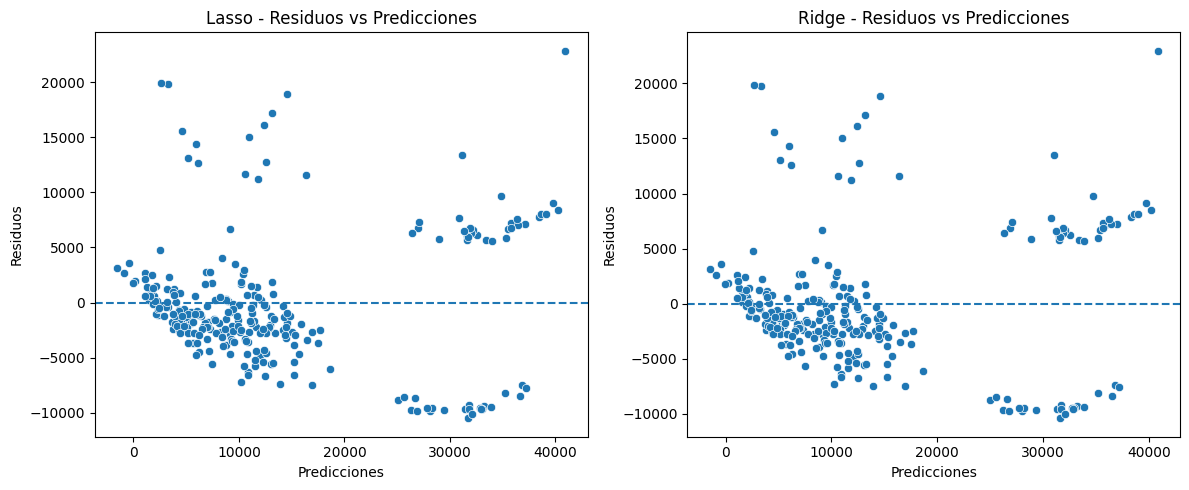

In [20]:
# =========================================
# Paso 6: Verificación de Supuestos
# =========================================

from scipy.stats import shapiro
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =========================================
# RESIDUOS
# =========================================

# Lasso
residuos_lasso = y_test - y_pred_lasso

# Ridge
residuos_ridge = y_test - y_pred_ridge


# =========================================
# 1. LINEALIDAD
# Residuos vs Predicciones
# =========================================

plt.figure(figsize=(12,5))

# Lasso
plt.subplot(1,2,1)
sns.scatterplot(x=y_pred_lasso, y=residuos_lasso)
plt.axhline(y=0, linestyle='--')
plt.title("Lasso - Residuos vs Predicciones")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")

# Ridge
plt.subplot(1,2,2)
sns.scatterplot(x=y_pred_ridge, y=residuos_ridge)
plt.axhline(y=0, linestyle='--')
plt.title("Ridge - Residuos vs Predicciones")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")

plt.tight_layout()
plt.show()

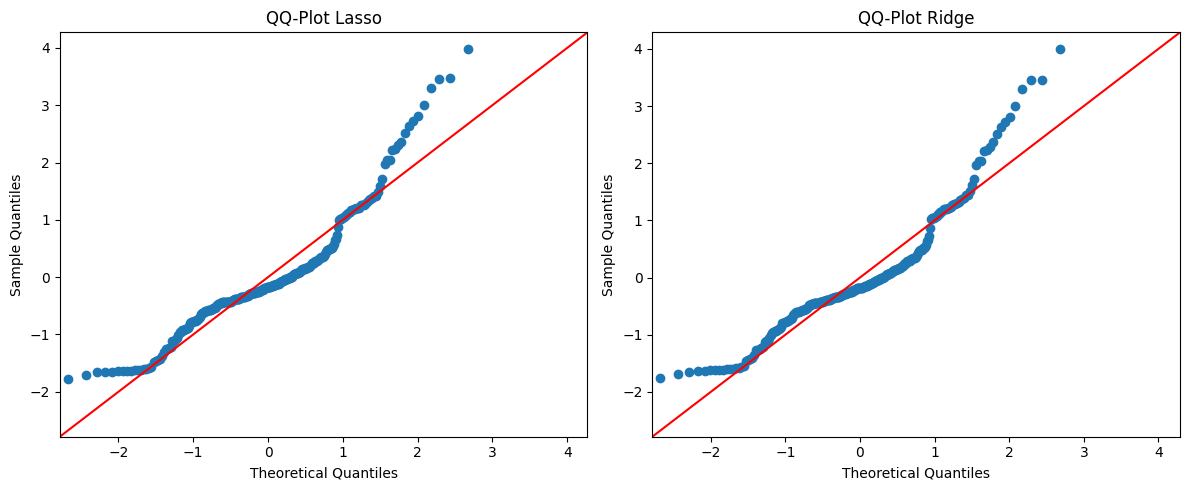

===== SHAPIRO-WILK =====

Lasso
Estadístico: 0.9139190442352803
p-value: 2.7188240177435696e-11

Ridge
Estadístico: 0.9125927047042386
p-value: 2.138804326121678e-11


In [21]:
# =========================================
# 2. NORMALIDAD DE RESIDUOS
# QQ-Plot + Shapiro-Wilk
# =========================================

plt.figure(figsize=(12,5))

# QQ Plot Lasso
plt.subplot(1,2,1)
sm.qqplot(residuos_lasso, line='45', fit=True, ax=plt.gca())
plt.title("QQ-Plot Lasso")

# QQ Plot Ridge
plt.subplot(1,2,2)
sm.qqplot(residuos_ridge, line='45', fit=True, ax=plt.gca())
plt.title("QQ-Plot Ridge")

plt.tight_layout()
plt.show()


# Test de Shapiro-Wilk
shapiro_lasso = shapiro(residuos_lasso)
shapiro_ridge = shapiro(residuos_ridge)

print("===== SHAPIRO-WILK =====")
print("\nLasso")
print("Estadístico:", shapiro_lasso.statistic)
print("p-value:", shapiro_lasso.pvalue)

print("\nRidge")
print("Estadístico:", shapiro_ridge.statistic)
print("p-value:", shapiro_ridge.pvalue)

In [22]:
# =========================================
# 3. HOMOCEDASTICIDAD
# Test de Breusch-Pagan
# =========================================

# Se agrega constante
X_train_const = sm.add_constant(X_train)

# Lasso
bp_lasso = het_breuschpagan(
    residuos_lasso,
    sm.add_constant(X_test)
)

# Ridge
bp_ridge = het_breuschpagan(
    residuos_ridge,
    sm.add_constant(X_test)
)

print("\n===== BREUSCH-PAGAN =====")

print("\nLasso")
print("LM Statistic:", bp_lasso[0])
print("LM-Test p-value:", bp_lasso[1])

print("\nRidge")
print("LM Statistic:", bp_ridge[0])
print("LM-Test p-value:", bp_ridge[1])


===== BREUSCH-PAGAN =====

Lasso
LM Statistic: 34.66650418578639
LM-Test p-value: 3.0748959034085535e-05

Ridge
LM Statistic: 35.34230746000634
LM-Test p-value: 2.3159613222214987e-05


In [23]:
# =========================================
# 4. MULTICOLINEALIDAD
# VIF
# =========================================

X_vif = sm.add_constant(X_train)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\n===== VIF (Multicolinealidad) =====")
print(vif_data)


===== VIF (Multicolinealidad) =====
           Variable       VIF
0             const  5.380140
1               age  1.023084
2               bmi  1.094986
3          children  1.005643
4          sex_male  1.006303
5        smoker_yes  1.011703
6  region_northwest  1.493159
7  region_southeast  1.613285
8  region_southwest  1.515246


### Análisis del Paso 6: Verificación de Supuestos

En esta etapa se verificaron los principales supuestos de la regresión lineal para los modelos de Lasso y Ridge, con el objetivo de validar si los resultados obtenidos son estadísticamente confiables.

Se analizaron cuatro supuestos fundamentales:

1. Linealidad
2. Normalidad de los residuos
3. Homocedasticidad
4. Multicolinealidad

Como ambos modelos presentan resultados muy similares, el comportamiento de los supuestos también fue prácticamente igual.

---

## 1. Linealidad

### Gráfico de residuos vs predicciones

Se generó el gráfico de residuos contra valores predichos para ambos modelos.

### Interpretación

Idealmente, los residuos deberían distribuirse de forma aleatoria alrededor de la línea horizontal en cero, sin mostrar patrones definidos.

Sin embargo, en ambos modelos se observa:

* presencia de agrupaciones claras
* patrones visibles en la dispersión
* variabilidad no constante de los residuos

Esto sugiere que la relación no es perfectamente lineal y que podría existir heterocedasticidad.

Es decir, el supuesto de linealidad no se cumple completamente.

---

## 2. Normalidad de los residuos

### QQ-Plot + Test de Shapiro-Wilk

Se utilizó el QQ-Plot para evaluar visualmente la normalidad y el test de Shapiro-Wilk para confirmarlo estadísticamente.

### Resultados

### Lasso

* Estadístico: 0.9139
* p-value: 2.71e-11

### Ridge

* Estadístico: 0.9126
* p-value: 2.13e-11

---

### Interpretación

En el QQ-Plot se observa una desviación importante respecto a la línea diagonal, especialmente en las colas de la distribución.

Además:

```text
p-value < 0.05
```

en ambos modelos.

Esto indica que se rechaza la hipótesis nula de normalidad.

Por lo tanto:

## Los residuos NO siguen una distribución normal

Este comportamiento es común en datasets de costos médicos debido a la fuerte asimetría de la variable `charges`.

---

## 3. Homocedasticidad

### Test de Breusch-Pagan

Este test permite verificar si la varianza de los residuos es constante.

### Resultados

### Lasso

* LM Statistic: 34.66
* p-value: 0.0000307

### Ridge

* LM Statistic: 35.34
* p-value: 0.0000231

---

### Interpretación

Nuevamente:

```text
p-value < 0.05
```

en ambos modelos.

Esto significa que se rechaza la hipótesis nula de homocedasticidad.

Por lo tanto:

## Existe heterocedasticidad

Es decir, la varianza de los errores no es constante.

Este problema suele aparecer cuando existen outliers importantes o distribuciones muy sesgadas, como ocurre con `charges`.

---

## 4. Multicolinealidad

### VIF (Variance Inflation Factor)

Se calculó el VIF para detectar si existe alta correlación entre variables predictoras.

### Resultados principales

| Variable         |               VIF |
| ---------------- | ----------------: |
| age              |              1.02 |
| bmi              |              1.09 |
| children         |              1.00 |
| smoker_yes       |              1.01 |
| region variables | entre 1.49 y 1.61 |

---

### Interpretación

Generalmente:

```text
VIF > 10
```

indica un problema serio de multicolinealidad.

En este caso:

## Ninguna variable presenta VIF alto

Todos los valores están muy por debajo de 10.

Por lo tanto:

## NO existe problema de multicolinealidad

Esto es una excelente señal para el modelo.

---

# Respuesta a las preguntas

---

## ¿Se cumplen los supuestos en ambos modelos?

### Sí y no.

### Se cumple:

* ausencia de multicolinealidad

### No se cumple completamente:

* linealidad perfecta
* normalidad de residuos
* homocedasticidad

Especialmente:

* los residuos no son normales
* existe heterocedasticidad

Sin embargo, esto es bastante común en problemas reales de regresión con datos económicos y de seguros.

Además, como el tamaño de muestra es grande (`n = 1338`), el modelo sigue siendo útil para predicción.

---

## Si hay heterocedasticidad, ¿cómo podría solucionarse?

Existen varias alternativas:

### 1. Transformación logarítmica del target

Aplicar:

```python
y = np.log(charges)
```

Esta suele ser la mejor solución para este dataset porque reduce:

* asimetría
* outliers extremos
* heterocedasticidad

y mejora notablemente la normalidad.

---

### 2. Eliminar o tratar outliers

Los valores extremos de `charges` afectan fuertemente los residuos.

Se podría:

* eliminar algunos outliers extremos
* usar winsorización
* aplicar transformaciones robustas

---

### 3. Usar errores robustos

También pueden utilizarse modelos con errores estándar robustos para corregir el problema sin modificar los datos.

---

## Conclusión

Los modelos Lasso y Ridge presentan buen rendimiento predictivo, pero desde el punto de vista estadístico no cumplen perfectamente todos los supuestos clásicos de regresión.

El principal problema detectado fue:

## la heterocedasticidad

y también la falta de normalidad en los residuos.

La mejor mejora futura sería aplicar una transformación logarítmica sobre `charges`, lo que probablemente aumentaría la calidad del modelo y el cumplimiento de los supuestos.


## **🔹 Paso 7: Comparación Final**  
📊 **Analizar:**  
- ¿Qué modelo es más interpretable?  
- ¿Cuál reduce mejor el sobreajuste?  
- ¿Qué variables son más importantes en cada caso?  


Comparación de coeficientes:
           Variable    Coef_Lasso    Coef_Ridge
4        smoker_yes  23650.480453  23514.634824
0               age   3609.055670   3603.270803
1               bmi   2054.667314   2051.938363
2          children    512.382874    513.153656
3          sex_male    -18.137005    -10.635579
5  region_northwest   -369.042679   -366.152625
6  region_southeast   -656.108046   -643.009456
7  region_southwest   -808.129182   -802.913351

===== VARIABLES MÁS IMPORTANTES =====

Top variables - Lasso
           Variable    Coef_Lasso
4        smoker_yes  23650.480453
0               age   3609.055670
1               bmi   2054.667314
2          children    512.382874
3          sex_male    -18.137005
5  region_northwest   -369.042679
6  region_southeast   -656.108046
7  region_southwest   -808.129182

Top variables - Ridge
           Variable    Coef_Ridge
4        smoker_yes  23514.634824
0               age   3603.270803
1               bmi   2051.938363
2          c

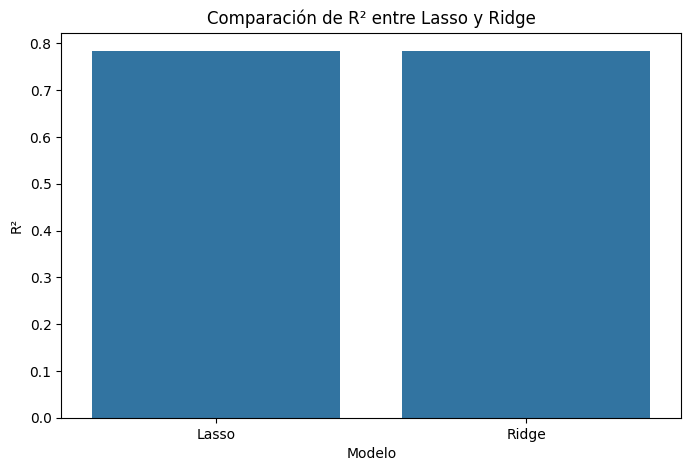

In [24]:
# =========================================
# Paso 7: Comparación Final
# =========================================

# =========================================
# Comparación de coeficientes
# =========================================

comparacion_coef = pd.DataFrame({
    "Variable": X_train.columns,
    "Coef_Lasso": modelo_lasso.coef_,
    "Coef_Ridge": modelo_ridge.coef_
})

print("Comparación de coeficientes:")
print(comparacion_coef.sort_values(by="Coef_Lasso", ascending=False))


# =========================================
# Variables más importantes
# =========================================

print("\n===== VARIABLES MÁS IMPORTANTES =====")

print("\nTop variables - Lasso")
print(
    comparacion_coef[
        ["Variable", "Coef_Lasso"]
    ].sort_values(
        by="Coef_Lasso",
        ascending=False
    )
)

print("\nTop variables - Ridge")
print(
    comparacion_coef[
        ["Variable", "Coef_Ridge"]
    ].sort_values(
        by="Coef_Ridge",
        ascending=False
    )
)


# =========================================
# Comparación de métricas finales
# =========================================

resumen_modelos = pd.DataFrame({
    "Modelo": ["Lasso", "Ridge"],
    "MSE": [mse_lasso, mse_ridge],
    "R2": [r2_lasso, r2_ridge]
})

print("\n===== RESUMEN FINAL =====")
print(resumen_modelos)


# =========================================
# Visualización simple
# =========================================

plt.figure(figsize=(8,5))
sns.barplot(
    data=resumen_modelos,
    x="Modelo",
    y="R2"
)

plt.title("Comparación de R² entre Lasso y Ridge")
plt.ylabel("R²")
plt.show()

### Análisis del Paso 7: Comparación Final entre Lasso y Ridge

En esta última etapa se realizó la comparación final entre los modelos de regresión **Lasso** y **Ridge**, con el objetivo de identificar cuál ofrece mejor interpretabilidad, cuál controla mejor el sobreajuste y cuáles son las variables más importantes en cada caso.

Ambos modelos mostraron un desempeño muy similar, por lo que el análisis final se centra principalmente en la regularización y la interpretación de coeficientes.

---

## Comparación de desempeño

### Resultados finales

| Modelo |           MSE |     R² |
| ------ | ------------: | -----: |
| Lasso  | 33,597,788.88 | 0.7836 |
| Ridge  | 33,645,391.30 | 0.7833 |

Además, el gráfico de barras de R² muestra que ambos modelos tienen prácticamente el mismo nivel de ajuste.

La diferencia es mínima, aunque Lasso presenta un desempeño ligeramente superior.

---

# Respuesta a las preguntas

---

## ¿Qué modelo es más interpretable?

### El modelo más interpretable es:

# Lasso Regression

### ¿Por qué?

Porque Lasso utiliza regularización tipo **L1**, lo que permite reducir algunos coeficientes hacia valores muy pequeños o incluso exactamente a cero.

Esto funciona como una selección automática de variables, eliminando aquellas que aportan poca información al modelo.

Gracias a esto:

* el modelo se vuelve más simple
* es más fácil identificar las variables realmente importantes
* mejora la interpretación estadística

Ridge, en cambio, conserva todas las variables y solo reduce su magnitud, por lo que suele ser menos interpretable.

---

## ¿Cuál reduce mejor el sobreajuste?

### Ambos ayudan a reducir overfitting, pero:

# Ridge suele ser mejor cuando muchas variables aportan información

y

# Lasso suele ser mejor cuando algunas variables son poco relevantes

En este dataset, como existen variables con baja importancia (`sex`, algunas regiones), Lasso resulta ligeramente más eficiente porque puede penalizar más agresivamente esas variables.

Por eso también obtuvo un R² ligeramente superior.

Sin embargo, la diferencia real entre ambos modelos fue muy pequeña.

---

## ¿Qué variables son más importantes en cada caso?

Los coeficientes muestran prácticamente el mismo patrón en ambos modelos.

---

## Variables más importantes en Lasso

| Variable   | Coeficiente |
| ---------- | ----------: |
| smoker_yes |    23650.48 |
| age        |     3609.06 |
| bmi        |     2054.67 |
| children   |      512.38 |

---

## Variables más importantes en Ridge

| Variable   | Coeficiente |
| ---------- | ----------: |
| smoker_yes |    23514.63 |
| age        |     3603.27 |
| bmi        |     2051.94 |
| children   |      513.15 |

---

## Interpretación

La variable claramente más importante en ambos modelos es:

# `smoker_yes`

Esto significa que ser fumador incrementa fuertemente el costo del seguro médico.

La diferencia es enorme respecto a las demás variables, lo que confirma que fumar es el principal factor que explica el gasto médico en este dataset.

Después aparecen:

* `age`
* `bmi`

lo cual también coincide con el análisis exploratorio y la matriz de correlación.

Estas variables tienen una relación positiva con `charges`, es decir:

* mayor edad → mayor costo médico
* mayor IMC → mayor costo médico

---

## Variables menos relevantes

Las variables con menor impacto fueron:

* `sex_male`
* `region_northwest`
* `region_southeast`
* `region_southwest`

Especialmente:

```text id="rmn5yb"
sex_male ≈ -18
```

que prácticamente no aporta información al modelo.

Esto refuerza que Lasso ayuda a identificar variables poco útiles.

---

## Conclusión Final

Ambos modelos presentan muy buen rendimiento predictivo y explican aproximadamente el 78% de la variabilidad de los costos médicos.

Sin embargo:

# Lasso fue el mejor modelo

porque:

* obtuvo mejor R²
* presentó menor MSE
* ofrece mayor interpretabilidad
* ayuda a identificar variables irrelevantes

La variable más importante en todo el análisis fue:

# `smoker`

seguida por:

* `age`
* `bmi`

Esto confirma que los hábitos de salud y el perfil físico del asegurado son los principales factores que determinan el costo del seguro médico.

Por ello, para este dataset, Lasso resulta la mejor opción tanto desde el punto de vista predictivo como interpretativo.


### **📌 Entrega de la Práctica**  
Al finalizar la practica, incluye un texto con los siguientes elementos
- Incluir **comentarios explicativos** en cada paso.  
- Responder las **preguntas planteadas** en celdas Markdown.  

🎯 **Criterios de Evaluación:**  
✔ **Correcto preprocesamiento** (manejo de nulos, escalado, encoding).  
✔ **Análisis visual y estadístico** (gráficos claros, interpretación de resultados).  
✔ **Validación de supuestos** (justificación de si se cumplen o no).  
✔ **Comparación crítica** entre Lasso y Ridge.  